Fetching economic data...
Data fetched successfully.

         MACROPULSE SCORE

MacroPulse Score: 76.0 / 100
Letter Grade: C
Environment: Stable Expansion

-----------------------------
LATEST ECONOMIC DATA
-----------------------------
Unemployment Rate: 4.30% (Date: 2026-04-01)
Inflation Rate: 3.78% (Date: 2026-04-01)
Fed Funds Rate: 3.64% (Date: 2026-04-01)

-----------------------------
COMPONENT SCORES
-----------------------------
Labor Market Score: 75
Inflation Score: 60
Interest Rate Score: 100


/Users/anthonysardina/Desktop/PortfolioProjects/macropulse2/notebooks/../src/indicators.py:28: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df[column_name].pct_change(periods=periods) * 100


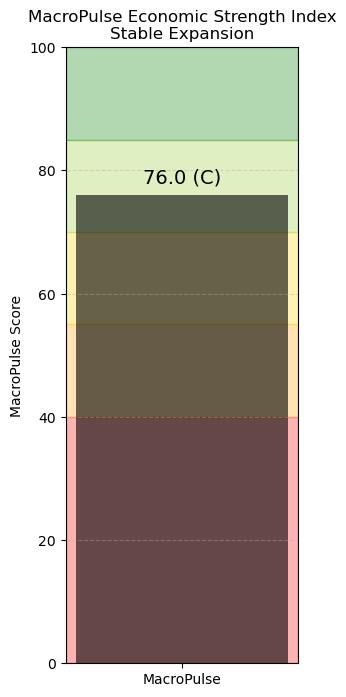

In [11]:
# ============================================================
# MacroPulse
# ============================================================

# -----------------------
# Project imports
# -----------------------

import sys
sys.path.append("../src")

from fred_client import (
    get_unemployment_data,
    get_cpi_data,
    get_fed_funds_rate
)

from indicators import (
    calculate_pct_change
)

from scoring import (
    calculate_macropulse_score,
    classify_macropulse_environment,
    get_letter_grade
)

# -----------------------
# External libraries
# -----------------------

import matplotlib.pyplot as plt

# ============================================================
# API KEY
# ============================================================

api_key = "d2e30f6dc49002d239eddfcff049d543"

# ============================================================
# FETCH DATA
# ============================================================

print("Fetching economic data...")

unrate = get_unemployment_data(api_key)

cpi = get_cpi_data(api_key)

fedfunds = get_fed_funds_rate(api_key)

print("Data fetched successfully.")

# ============================================================
# CREATE INFLATION RATE
# ============================================================

cpi = calculate_pct_change(
    cpi,
    "cpi",
    periods=12
)

cpi = cpi.rename(
    columns={
        "cpi_pct_change": "inflation_rate"
    }
)

# ============================================================
# GET LATEST VALUES + DATES
# ============================================================

latest_unemployment_row = unrate.iloc[-1]

latest_cpi_row = (
    cpi
    .dropna(subset=["inflation_rate"])
    .iloc[-1]
)

latest_fed_row = fedfunds.iloc[-1]

# Values

latest_unemployment = (
    latest_unemployment_row["unemployment_rate"]
)

latest_inflation = (
    latest_cpi_row["inflation_rate"]
)

latest_fed_rate = (
    latest_fed_row["fed_funds_rate"]
)

# Dates

latest_unemployment_date = (
    latest_unemployment_row["date"]
)

latest_inflation_date = (
    latest_cpi_row["date"]
)

latest_fed_date = (
    latest_fed_row["date"]
)

# ============================================================
# CALCULATE MACROPULSE SCORE
# ============================================================

results = calculate_macropulse_score(
    unemployment_rate=latest_unemployment,
    inflation_rate=latest_inflation,
    fed_funds_rate=latest_fed_rate
)

environment = classify_macropulse_environment(
    results["macropulse_score"]
)

letter_grade = get_letter_grade(
    results["macropulse_score"]
)

# ============================================================
# DISPLAY RESULTS
# ============================================================

print("\n===================================")
print("         MACROPULSE SCORE")
print("===================================")

print(
    f"\nMacroPulse Score: "
    f"{results['macropulse_score']} / 100"
)

print(f"Letter Grade: {letter_grade}")

print(f"Environment: {environment}")

print("\n-----------------------------")
print("LATEST ECONOMIC DATA")
print("-----------------------------")

print(
    f"Unemployment Rate: "
    f"{latest_unemployment:.2f}% "
    f"(Date: {latest_unemployment_date.date()})"
)

print(
    f"Inflation Rate: "
    f"{latest_inflation:.2f}% "
    f"(Date: {latest_inflation_date.date()})"
)

print(
    f"Fed Funds Rate: "
    f"{latest_fed_rate:.2f}% "
    f"(Date: {latest_fed_date.date()})"
)

print("\n-----------------------------")
print("COMPONENT SCORES")
print("-----------------------------")

print(
    f"Labor Market Score: "
    f"{results['labor_market_score']}"
)

print(
    f"Inflation Score: "
    f"{results['inflation_score']}"
)

print(
    f"Interest Rate Score: "
    f"{results['interest_rate_score']}"
)

# ============================================================
# MACROPULSE VISUALIZATION
# ============================================================

plt.figure(figsize=(3, 8))

score = results["macropulse_score"]

# Background score zones

plt.axhspan(0, 40, alpha=0.3, color="red")
plt.axhspan(40, 55, alpha=0.3, color="orange")
plt.axhspan(55, 70, alpha=0.3, color="gold")
plt.axhspan(70, 85, alpha=0.3, color="yellowgreen")
plt.axhspan(85, 100, alpha=0.3, color="green")

# Vertical score bar

plt.bar(
    x=["MacroPulse"],
    height=[score],
    width=0.03,
    color = "black",
    alpha=0.6
)

# Score text

plt.text(
    0,
    score + 2,
    f"{score} ({letter_grade})",
    ha="center",
    fontsize=14
)

# Formatting

plt.ylim(0, 100)

plt.ylabel("MacroPulse Score")

plt.title(
    f"MacroPulse Economic Strength Index\n{environment}"
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()